# Día 8 · Unidad 8 — Visualización (III): matrix plots, `heatmap` y `clustermap`

**Objetivos de aprendizaje**
- Medir la asociación entre variables categóricas con la V de Cramér.
- Construir mapas de calor (`sns.heatmap()`) de correlaciones numéricas y de asociación categórica.
- Combinar `pivot_table()` (visto en `02_teoria_merge_concat_pivot_io.ipynb`) con `heatmap` para visualizar una serie temporal en formato año × mes.
- Usar `sns.clustermap()` para reordenar filas/columnas de una matriz según similitud.

**Duración estimada:** 60-75 minutos.

**Requisitos previos:** `04_teoria_seaborn_distribucion_categorica.ipynb` de este mismo día, y `02_teoria_merge_concat_pivot_io.ipynb` (pivot_table).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

cartera = pd.read_csv("../data/raw/cartera_polizas.csv")
siniestros = pd.read_csv("../data/raw/siniestros.csv")
primas_mensuales = pd.read_csv("../data/raw/primas_mensuales.csv")

## 1. La V de Cramér: asociación entre variables categóricas

La correlación de Pearson que ya conocéis (Unidad 10) solo tiene sentido entre variables **numéricas**. Para medir el grado de asociación entre dos variables **categóricas**, una alternativa habitual es la [V de Cramér](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V): un valor continuo entre 0 y 1, donde 0 significa que la distribución cruzada de ambas variables es perfectamente uniforme (sin asociación) y 1 que hay una asociación total.

In [2]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Calcula la V de Cramér entre dos variables categóricas.

    Args:
        x: primera variable categórica.
        y: segunda variable categórica, con el mismo número de observaciones que x.

    Returns:
        float: valor entre 0 (sin asociación) y 1 (asociación total).
    """
    from scipy.stats import chi2_contingency

    tabla_cruzada = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla_cruzada, correction=False)[0]
    n = tabla_cruzada.sum().sum()
    dimension_minima = min(tabla_cruzada.shape) - 1
    return np.sqrt((chi2 / n) / dimension_minima)


def cramers_corr(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula la matriz de V de Cramér entre todas las columnas categóricas de un DataFrame.

    Args:
        df: DataFrame de origen.

    Returns:
        pd.DataFrame: matriz cuadrada (columnas categóricas x columnas categóricas)
        con la V de Cramér de cada par.
    """
    columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns
    matriz = pd.DataFrame(
        data=np.zeros((len(columnas_categoricas), len(columnas_categoricas))),
        columns=columnas_categoricas,
        index=columnas_categoricas,
    )
    for i, col_x in enumerate(columnas_categoricas):
        for col_y in columnas_categoricas[i:]:
            valor = 1.0 if col_x == col_y else cramers_v(df[col_x], df[col_y])
            matriz.loc[col_x, col_y] = valor
            matriz.loc[col_y, col_x] = valor
    return matriz

Aplicado a las columnas categóricas de `siniestros`:

In [3]:
columnas_interes = siniestros[["producto", "provincia", "tipo_siniestro", "estado"]]
matriz_cramer = cramers_corr(columnas_interes)
matriz_cramer.round(3)

,producto,provincia,tipo_siniestro,estado
producto,1.000,0.105,0.915,0.030
provincia,0.105,1.000,0.110,0.070
tipo_siniestro,0.915,0.110,1.000,0.092
estado,0.030,0.070,0.092,1.000


¿Qué significa que `producto` y `tipo_siniestro` tengan un valor alto? Tiene sentido de negocio: cada producto tiene su propio catálogo de tipos de siniestro (una `hospitalizacion` solo puede darse en `SALUD`, una `colision` solo en `AUTO`...), así que conocer uno predice mucho del otro. Podemos comprobarlo con la tabla cruzada real:

In [4]:
pd.crosstab(siniestros["producto"], siniestros["tipo_siniestro"])

tipo_siniestro,asistencia_en_carretera,averia_electrodomesticos,cirugia,colision,consulta_especialista,danos_por_agua,fallecimiento,hospitalizacion,incendio,invalidez,robo,rotura_lunas
producto,,,,,,,,,,,,
AUTO,158,0,0,152,0,0,0,0,156,0,139,155
HOGAR,0,71,0,0,0,49,0,0,68,0,68,0
SALUD,0,0,56,0,58,0,0,57,0,0,0,0
VIDA,0,0,0,0,0,0,5,0,0,8,0,0


Efectivamente: cada tipo de siniestro aparece casi en exclusiva bajo un único producto — de ahí la asociación tan alta.

## 2. `sns.heatmap()`: mapas de calor

### Correlación numérica

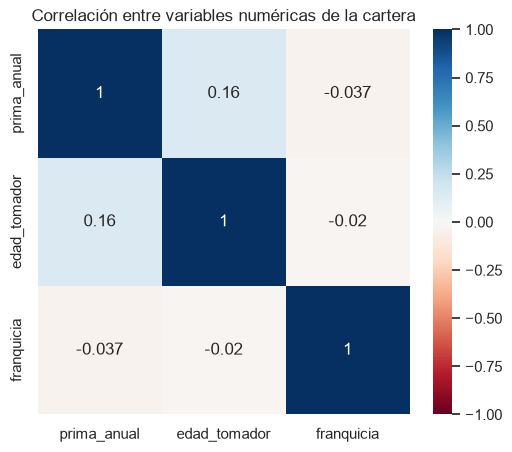

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
correlacion = cartera[["prima_anual", "edad_tomador", "franquicia"]].corr(numeric_only=True)
sns.heatmap(correlacion, vmin=-1, vmax=1, center=0, annot=True, cmap="RdBu", ax=ax)
ax.set_title("Correlación entre variables numéricas de la cartera")
plt.show()

### Matriz de V de Cramér

Igual que arriba, pero con `vmin=0` (la V de Cramér nunca es negativa) y un `cmap` de un solo extremo, no divergente — usar aquí un `cmap` divergente como `"RdBu"` sería el mismo error de paleta que visteis en el bloque de IA del notebook anterior: sugeriría que hay valores "negativos" cuando la V de Cramér no puede serlo.

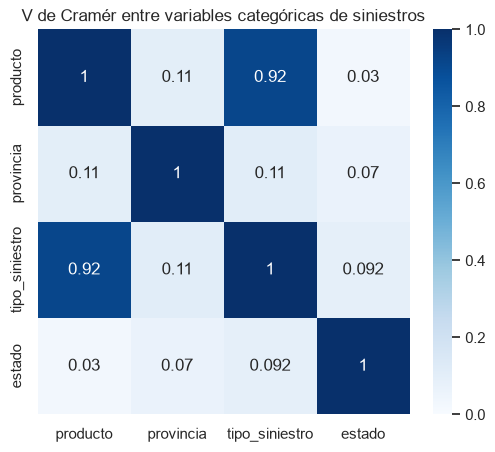

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matriz_cramer, vmin=0, vmax=1, center=0.5, annot=True, cmap="Blues", ax=ax)
ax.set_title("V de Cramér entre variables categóricas de siniestros")
plt.show()

### Con `pivot_table`: una serie temporal año × mes

Este es el uso más clásico de `heatmap`: convertir una serie temporal larga en una matriz año × mes, para ver de un vistazo la estacionalidad. Usamos `primas_mensuales.csv`, exactamente con el propósito para el que se generó (sustituye a `sns.load_dataset('flights')`, que tenía la misma estructura año × mes pero para pasajeros de avión, no para primas de seguros).

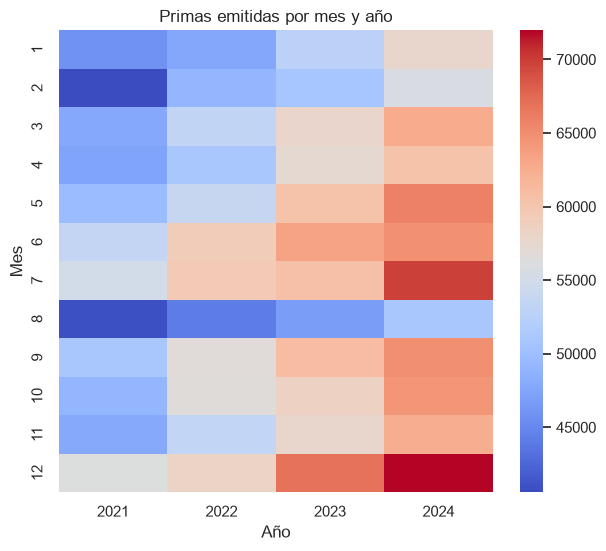

In [7]:
pivot_primas = primas_mensuales.pivot_table(
    values="primas_emitidas",
    index="mes",
    columns="anio",
    aggfunc="sum",
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivot_primas, cmap="coolwarm", annot=False, ax=ax)
ax.set_title("Primas emitidas por mes y año")
ax.set_ylabel("Mes")
ax.set_xlabel("Año")
plt.show()

> 📊 **En Excel esto sería...** un Formato Condicional de "escala de color" aplicado sobre una Tabla Dinámica con meses en filas y años en columnas: cada celda se colorea según su valor, permitiendo detectar patrones de estacionalidad (por ejemplo, más primas emitidas en según qué meses) de un vistazo, sin tener que leer los números uno a uno.

**Para ti:** repetid el `pivot_table` + `heatmap`, pero filtrando `primas_mensuales` a un único `producto` (por ejemplo `"AUTO"`) antes de pivotar. ¿Se aprecia algún patrón estacional distinto al del conjunto completo?

In [8]:
# Tu código aquí


## 3. `sns.clustermap()`: reordenar por similitud

[`sns.clustermap()`](https://seaborn.pydata.org/generated/seaborn.clustermap.html) dibuja un `heatmap`, pero **reordena** filas y columnas según un clúster jerárquico de similitud — en vez de mantener el orden original (aquí, cronológico), agrupa juntos los meses/años que se comportan de forma parecida.

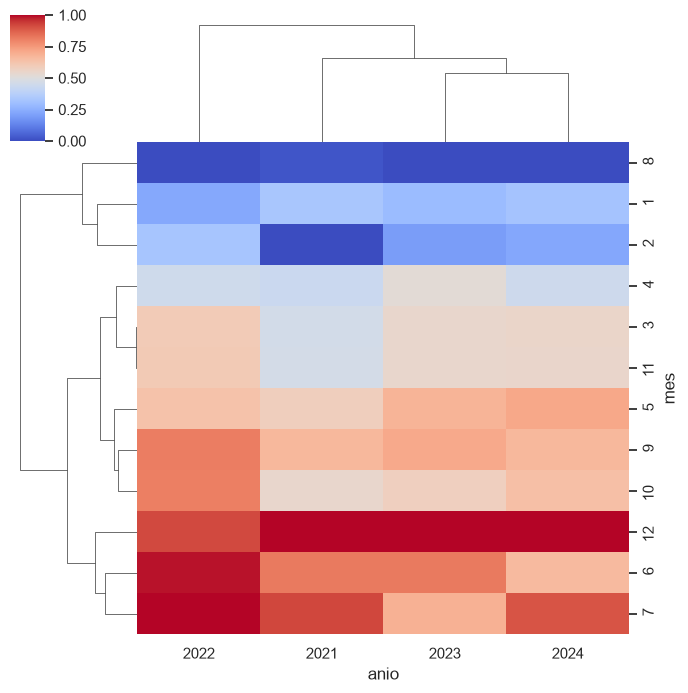

In [9]:
sns.clustermap(pivot_primas, cmap="coolwarm", standard_scale=1, figsize=(7, 7))
plt.show()

`standard_scale=1` normaliza cada columna (cada año) a la misma escala antes de agrupar, para que el clustering se base en la **forma** de la estacionalidad de cada año, no en su nivel absoluto (un año con más pólizas emitidas en general no debería "destacar" solo por tener números más altos en todos los meses).

> ⚠️ **Error típico**: interpretar el `heatmap`/`clustermap` sin fijarse en la escala de color (`vmin`/`vmax`/`cmap`). Dos `heatmap`s del mismo dato pueden "verse" muy distintos según los límites de color elegidos — un rango de color muy ajustado exagera diferencias pequeñas, uno muy amplio las esconde. Antes de sacar una conclusión de un mapa de calor, comprobad siempre la leyenda de color, no solo el patrón visual.

## Resumen

- La V de Cramér mide asociación entre variables **categóricas** (equivalente categórico de la correlación de Pearson entre numéricas); va de 0 (sin asociación) a 1 (asociación total).
- `sns.heatmap()` codifica una matriz con color — funciona igual de bien para correlaciones numéricas, matrices de V de Cramér, o cualquier tabla año × categoría construida con `pivot_table()`.
- La elección de `cmap` importa tanto como los datos: un `cmap` divergente (`"RdBu"`) para datos que pueden ser negativos y positivos (correlación de Pearson), uno de un solo extremo (`"Blues"`) para datos que nunca son negativos (V de Cramér, conteos).
- `pivot_table()` + `heatmap()` es el patrón clásico para visualizar estacionalidad (año × mes) — el mismo propósito que tenía originalmente `sns.load_dataset('flights')`, aquí con `primas_mensuales.csv`.
- `sns.clustermap()` reordena filas/columnas por similitud en vez de mantener el orden original — útil para detectar qué periodos se comportan de forma parecida entre sí.
- Al interpretar cualquier mapa de calor, comprobad siempre la escala de color (`vmin`/`vmax`) antes de sacar conclusiones del patrón visual: los mismos datos pueden "parecer" muy distintos según dónde se pongan los límites.

**Siguiente:** `06_ejercicios.ipynb`, donde practicaréis pandas avanzado y visualización sobre los datasets de hoy — incluida una versión del ejercicio `emblem_plot()`.